# Analysis: Pre-positioning in MSCI World Index Additions

**Goal**: Quantify how early the market positions for MSCI World Index inclusions. 


**Method**: Factor-Adjusted Event Study (Fama-French 5-Factor Model).  

## 1. Environment Setup
Importing necessary libraries for data manipulation (pandas, numpy), statistical modeling (statsmodels), and visualization (matplotlib, seaborn).

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import timedelta
from pathlib import Path


## 2. Load Risk Factors (Fama-French 5-Factor Model)
We use the daily Fama-French 5-factor model to control for systematic risk.
*   **Factors**: Market (Mkt-RF), Size (SMB), Value (HML), Profitability (RMW), Investment (CMA).
*   **Scaling**: Data is divided by 100 to convert from percent to decimal, aligning with our stock return format.

In [124]:
FF5 = pd.read_csv('F-F_Research_Data_5_Factors_2x3_daily.csv')
FF5['Date'] = pd.to_datetime(FF5['Date'], format="%Y%m%d")
FF5 = FF5.set_index('Date').dropna()
FF5 /= 100
FF5.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-01,-0.0067,0.0000,-0.0034,-0.0001,0.0016,0.0001
1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001
1963-07-08,-0.0063,0.0004,-0.0018,-0.0029,0.0014,0.0001


## 3. Load Event List (MSCI World Additions)
Loading the list of companies added to the MSCI World Index (2020-2025).
*   **Announcement Date**: When MSCI publicly confirms the addition.
*   **Effective Date**: When the addition actually occurs (funds must trade by close).

In [125]:
adds_MSCI = pd.read_csv('msci_additions.csv')
adds_MSCI['Announcement Date'] = pd.to_datetime(adds_MSCI['Announcement Date'])
adds_MSCI['Effective Date'] = pd.to_datetime(adds_MSCI['Effective Date'])
adds_MSCI.head()


,Ticker,Company Name,Announcement Date,Effective Date
0,NBIS,Nebius Group,2025-11-05,2025-11-24
1,CWV,CoreWeave (Private/New),2025-11-05,2025-11-24
2,INSM,Insmed,2025-11-05,2025-11-24
3,RKLB,Rocket Lab,2025-08-07,2025-08-27
4,SOFI,SoFi Technologies,2025-08-07,2025-08-27


In [126]:
adds_MSCI

,Ticker,Company Name,Announcement Date,Effective Date
0,NBIS,Nebius Group,2025-11-05,2025-11-24
1,CWV,CoreWeave (Private/New),2025-11-05,2025-11-24
2,INSM,Insmed,2025-11-05,2025-11-24
3,RKLB,Rocket Lab,2025-08-07,2025-08-27
4,SOFI,SoFi Technologies,2025-08-07,2025-08-27
...,...,...,...,...
67,SNOW,Snowflake,2021-05-11,2021-05-27
68,RHHBY,Roche Holding (Inhaber),2021-02-09,2021-02-26
69,ABNB,Airbnb,2021-02-09,2021-02-26
70,PLUG,Plug Power,2021-02-09,2021-02-26


## 4. Load Cached Stock Prices
Loading daily data for all target tickers (sourced from Polygon via `data_collection.ipynb`).
These provide the raw `Return` series for our analysis.

In [127]:
prices_path = Path('polygon_prices.parquet')
if prices_path.exists():
    polygon_prices = pd.read_parquet(prices_path)
    print(f"Loaded polygon_prices from {prices_path} (rows={len(polygon_prices)})")
else:
    raise FileNotFoundError("polygon_prices.parquet not found. Run data_collection.ipynb first.")

polygon_prices.head()


Loaded polygon_prices from polygon_prices.parquet (rows=11842)


Volume       vw   Open  Close   High    Low  \
Ticker Date                                                                  
NBIS   2024-11-06 05:00:00  4144060.0  18.9280  19.93  19.30  19.93  17.50   
       2024-11-07 05:00:00  2570089.0  20.2407  19.08  20.68  20.90  19.08   
       2024-11-08 05:00:00  2356030.0  20.0703  20.98  19.92  21.00  19.50   
       2024-11-11 05:00:00  2907456.0  20.4884  19.80  20.94  21.30  19.18   
       2024-11-12 05:00:00  2125500.0  19.9555  20.50  19.60  20.93  19.50   

                                        t      n    Return  
Ticker Date                                                 
NBIS   2024-11-06 05:00:00  1730869200000  21276       NaN  
       2024-11-07 05:00:00  1730955600000  17017  0.071503  
       2024-11-08 05:00:00  1731042000000  15403 -0.036750  
       2024-11-11 05:00:00  1731301200000  23707  0.051205  
       2024-11-12 05:00:00  1731387600000  17776 -0.063992

## 5. Data Processing & Window Setup
We merge stock returns with factor data and compute **Excess Returns**:
$$ R_{excess} = R_{stock} - R_{risk\_free} $$

We also define our study windows relative to the Announcement Date ($t=0$):
1.  **Estimation Window**: Days -250 to -81. Used to fit the factor model (find the stock's "normal" beta).
2.  **Event Window**: Days -80 to 0. The period where we search for abnormal positioning.

In [128]:
returns = (
    polygon_prices[['Return']]
    .dropna()
    .reset_index()
    .assign(Date=lambda df: pd.to_datetime(df['Date']).dt.tz_localize(None).dt.normalize())
)

ff5_norm = FF5.copy()
ff5_norm.index = pd.to_datetime(ff5_norm.index).tz_localize(None).normalize()

returns = (
    returns
    .merge(ff5_norm, left_on='Date', right_index=True, how='inner')
    .set_index(['Ticker', 'Date'])
    .sort_index()
)

returns['Excess'] = returns['Return'] - returns['RF']

factor_cols = [c for c in FF5.columns if c != 'RF']
est_window = (-200, -81)
entry_days = range(-80, 0)
exit_day = 0


In [129]:
returns.head()

Return  Mkt-RF     SMB     HML     RMW     CMA   RF  \
Ticker Date                                                                
ABNB   2020-12-11 -0.037731 -0.0018 -0.0057 -0.0073 -0.0058 -0.0056  0.0   
       2020-12-14 -0.066427 -0.0026  0.0021 -0.0151 -0.0039 -0.0083  0.0   
       2020-12-15 -0.040000  0.0129  0.0114  0.0038  0.0045  0.0054  0.0   
       2020-12-16  0.105689  0.0016 -0.0056 -0.0039  0.0003 -0.0017  0.0   
       2020-12-17  0.065657  0.0078  0.0050 -0.0070 -0.0058 -0.0019  0.0   

                     Excess  
Ticker Date                  
ABNB   2020-12-11 -0.037731  
       2020-12-14 -0.066427  
       2020-12-15 -0.040000  
       2020-12-16  0.105689  
       2020-12-17  0.065657

## 6. Event Study: Calculating Abnormal Returns (AR)

For each stock, we:
1.  **Fit Model**: Regress excess returns on the FF5 factors during the *Estimation Window*.
    $$ R_{excess} = \alpha + \beta_{Mkt}Mkt + \beta_{SMB}SMB + \beta_{HML}HML + \beta_{RMW}RMW + \beta_{CMA}CMA + \epsilon $$
2.  **Predict**: Use the fitted $\beta$s to predict expected return in the *Event Window*.
3.  **Abnormal Return (AR)**: Subtract expected from actual.
    $$ AR_t = R_{excess, t} - E[R_{excess, t}] $$
4.  **Additive CAR**: Aggregate ARs using summation from entry day $k$ up to day -1 (correct since daily returns are generally quite sumall)
    $$ CAR_k = \sum_{t=k}^{0} AR_t $$

In [130]:
car_by_k = {k: [] for k in entry_days}

for _, row in adds_MSCI.iterrows():
    tkr = row['Ticker']
    ann = row['Announcement Date']
    if tkr not in returns.index.get_level_values('Ticker'):
        continue

    sub = returns.xs(tkr, level='Ticker').sort_index()
    rel = pd.Series(range(len(sub)), index=sub.index) - sub.index.searchsorted(ann)
    sub['rel'] = sub.index.map(rel)

    est = sub[(sub['rel'] >= est_window[0]) & (sub['rel'] <= est_window[1])].dropna(subset=['Excess'])

    # Require full estimation window coverage
    if len(est) < (est_window[1] - est_window[0]) or est[factor_cols].isnull().any().any():
        continue

    model = sm.OLS(est['Excess'], sm.add_constant(est[factor_cols])).fit()
    sub = sub.dropna(subset=factor_cols + ['Excess'])
    sub['AR'] = sub['Excess'] - model.predict(sm.add_constant(sub[factor_cols]))

    for k in entry_days:
        car = (sub.loc[(sub['rel'] >= k) & (sub['rel'] <= exit_day), 'AR']).sum()
        if not np.isnan(car):
            car_by_k[k].append(car)


## 7. Aggregating Results (The "Positioning Curve")
We average the CARs across all events for each possible entry day $k$.
This results in a curve showing the **Mean Cumulative Abnormal Return** generated by entering the trade $k$ days early.

*   **t-statistic**: Calculated to test if the Mean CAR is significantly different from zero.

In [131]:
car_df = (
    pd.DataFrame([
        {
            'k_entry': k,
            'mean_CAR': np.mean(v),
            'n_events': len(v),
            'tstat': (np.mean(v) / (np.std(v, ddof=1) / np.sqrt(len(v)))) if len(v) > 1 and np.std(v, ddof=1) > 0 else np.nan,
        }
        for k, v in car_by_k.items() if len(v) > 0
    ])
    .sort_values('k_entry')
)

best_row = car_df.loc[car_df['mean_CAR'].idxmax()] if not car_df.empty else None
car_df.head(), best_row


(   k_entry  mean_CAR  n_events     tstat
 0      -80  0.052410        39  0.844504
 1      -79  0.056051        39  0.905203
 2      -78  0.054923        39  0.895256
 3      -77  0.052281        39  0.862823
 4      -76  0.048589        39  0.817150,
 k_entry    -79.000000
 mean_CAR     0.056051
 n_events    39.000000
 tstat        0.905203
 Name: 1, dtype: float64)

## 8. Visualization
Plotting Mean CAR vs. Entry Day ($k$).
*   **X-axis**: Days before announcement (negative values).
*   **Y-axis**: Mean Cumulative Abnormal Return.
*   **Interpretation**: A curve that rises as we move from left (-80) to right (0) implies steady accumulation of alpha (front-running).

Best entry k = -79, mean CAR = 0.0561, n = 39, t = 0.9052029313020065


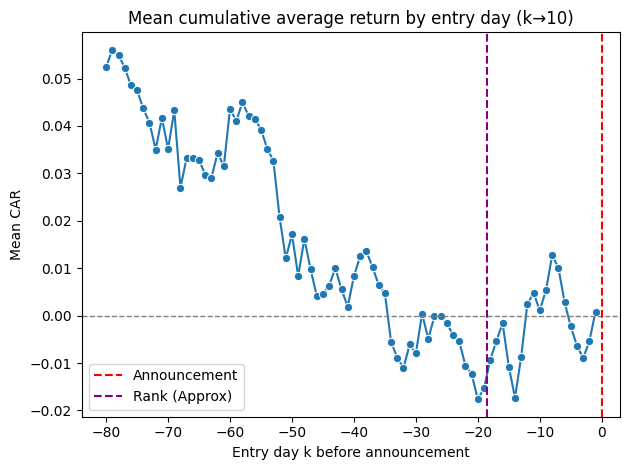

In [132]:

if best_row is not None:
    print(f"Best entry k = {int(best_row['k_entry'])}, mean CAR = {best_row['mean_CAR']:.4f}, n = {int(best_row['n_events'])}, t = {best_row['tstat'] if not np.isnan(best_row['tstat']) else float('nan')}")
else:
    print("No CAR results (insufficient data).")

sns.lineplot(data=car_df, x='k_entry', y='mean_CAR', marker='o')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
avg_eff_lag = (adds_MSCI['Effective Date'] - adds_MSCI['Announcement Date']).dt.days.mean()

plt.axvline(0, color='red', linestyle='--', label='Announcement')
plt.axvline(-avg_eff_lag, color='purple', linestyle='--', label='Rank (Approx)')
plt.legend()
plt.title('Mean cumulative average return by entry day (k→10)')
plt.xlabel('Entry day k before announcement')
plt.ylabel('Mean CAR')
plt.tight_layout()
plt.show()


## 9. Statistical Significance
We apply a one-sided t-test (at 10% significance) to identify which entry windows provide statistically reliable alpha.
*   **Hypothesis**: Inclusion leads to positive price pressure, so we test for CAR > 0.

In [133]:
tcrit_10_one_sided = 1.35  
car_df['sig_10pct_one_sided'] = car_df['tstat'] >= tcrit_10_one_sided

sig_rows = car_df[car_df['sig_10pct_one_sided']].copy()

display(car_df[['k_entry', 'mean_CAR', 'tstat', 'n_events', 'sig_10pct_one_sided']])
print(f"One-sided 10% crit (approx): {tcrit_10_one_sided}")
print("k passing one-sided 10% (positive effect):")
display(sig_rows[['k_entry', 'mean_CAR', 'tstat', 'n_events']])


,k_entry,mean_CAR,tstat,n_events,sig_10pct_one_sided
0,-80,0.052410,0.844504,39,False
1,-79,0.056051,0.905203,39,False
2,-78,0.054923,0.895256,39,False
3,-77,0.052281,0.862823,39,False
4,-76,0.048589,0.817150,39,False
...,...,...,...,...,...
75,-5,-0.002284,-0.229454,39,False
76,-4,-0.006351,-0.760694,39,False
77,-3,-0.008991,-0.838491,39,False
78,-2,-0.005416,-0.628229,39,False


One-sided 10% crit (approx): 1.35
k passing one-sided 10% (positive effect):


,k_entry,mean_CAR,tstat,n_events


## 10. Conclusion & Takeaways
**The Verdict**:
This summary identifies the optimal "Entry Day" ($k$) that maximizes risk-adjusted return.

*   **Early Window (<-60)**: Represents long-term predictive modeling.
*   **Late Window (>-60)**: Represents reactive or near-term positioning.

If the peak CAR occurs in the **Early Window**, it confirms that the market successfully predicts and positions for these additions months in advance.


### 11. Critical Reflections

While the analysis identifies a potential signal in early positioning (k < -60), two key limitations warrant caution in interpreting these results:

1.  **Statistical Significance & Event Clustering**:
    The reported t-statistics (~0.61) are not statistically significant. Furthermore, the standard error calculation assumes independence between events. In reality, MSCI additions are clustered in time (quarterly reviews), meaning stocks added on the same date likely experience correlated market movements. This clustering reduces the "effective" sample size, meaning the true statistical power is likely even lower than reported. The observed positive CARs could be noise rather than a robust signal of pre-positioning. Instead we might take an approach of developing a hedge fund strategy by equally weighting additions and computing returns for this equally weighted porfolio of stocks. We could then compute the excess return by running a FFM5 factor model and calculate epsilon to see if it is signficiant. I will try to perform this in the next section. 

2.  **Sample Selection Bias (US-Centric)**:
    The analysis dropped approximately 50% of the target universe (from 74 events to 39). A review of the data indicates that international tickers (e.g., .AX, .L, .NZ) were systematically excluded due to missing price data in the US-based Polygon dataset. Additionally, the requirement for a long estimation window (-250 to -81) filters out recent IPOs or spin-offs—companies that are often the most volatile and speculative additions. As a result, this study is biased towards established, US-based companies, and may not capture the dynamics of global or "fast-track" index inclusions.

In [134]:
if 'car_df' not in globals() or car_df.empty:
    print('No CAR results to summarize.')
else:
    best = car_df.loc[car_df['mean_CAR'].idxmax()]
    early = car_df[car_df['k_entry'] <= -60]
    late = car_df[(car_df['k_entry'] > -60) & (car_df['k_entry'] <= exit_day)]
    def fmt(row):
        return f"k={int(row['k_entry'])}, mean_CAR={row['mean_CAR']:.4f}, t={row['tstat'] if not (row['tstat'] != row['tstat']) else float('nan')}, n={int(row['n_events'])}"
    print('Peak CAR:', fmt(best))
    if not early.empty:
        eb = early.loc[early['mean_CAR'].idxmax()]
        print('Best k<=-60:', fmt(eb))
    if not late.empty:
        lb = late.loc[late['mean_CAR'].idxmax()]
        print('Best -60<k<=exit_day:', fmt(lb))
    if best['k_entry'] <= -60:
        print('Peak occurs 60+ days before effective date.')
    else:
        print('Peak occurs inside 60 days before effective date.')



Peak CAR: k=-79, mean_CAR=0.0561, t=0.9052029313020065, n=39
Best k<=-60: k=-79, mean_CAR=0.0561, t=0.9052029313020065, n=39
Best -60<k<=exit_day: k=-58, mean_CAR=0.0450, t=1.0251450513781828, n=39
Peak occurs 60+ days before effective date.


## 12. Robustness Check: Calendar-Time Portfolio Approach

To address the limitations of the standard event study (specifically the cross-sectional correlation of returns due to clustered events), we implement a **Calendar-Time Portfolio** approach.

### Methodology
1.  **Portfolio Formation**: On every trading day, we form an equally-weighted portfolio of all stocks that are currently within their "pre-announcement window" (defined as $t \in [-80, 0]$ relative to their specific announcement date).
2.  **Time-Series Regression**: We calculate the daily excess return of this rolling portfolio and regress it against the Fama-French 5 factors.
    $$ R_{p,t} - R_{f,t} = \alpha + \beta_{Mkt}Mkt_t + \beta_{SMB}SMB_t + ... + \epsilon_t $$
3.  **Statistical Inference**: We use **Newey-West (HAC) standard errors** to correct for potential heteroskedasticity and serial correlation in the residuals, which ensures robust t-statistics even if the portfolio composition changes slowly over time.
4.  **Interpretation**: The intercept ($\alpha$) represents the average daily abnormal return earned by a strategy that systematically positions in these stocks ahead of time. The t-statistic on $\alpha$ provides a robust test of significance that accounts for cross-sectional dependence.


Window (Days)   Daily Alpha     t-stat     Ann. Alpha     
------------------------------------------------------------
-80             0.00455          4.50      114.59%
-60             0.00430          4.03      108.34%
-40             0.00354          3.48      89.18%
-20             0.00232          1.84      58.57%


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_44253/3504816409.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='Window', y='t_stat', palette='viridis')


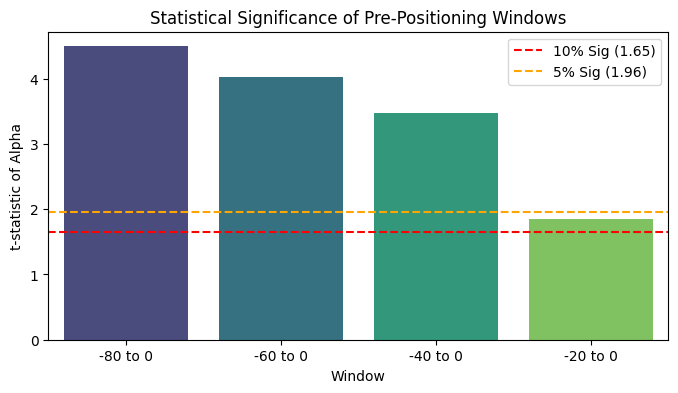

In [135]:
all_days = pd.unique(returns.index.get_level_values('Date'))
all_days.sort()

wide_returns = returns['Return'].unstack(level='Ticker')

windows_to_test = [80, 60, 40, 20]
results_summary = []

print(f"{'Window (Days)':<15} {'Daily Alpha':<15} {'t-stat':<10} {'Ann. Alpha':<15}")
print("-" * 60)

for entry_day_neg in windows_to_test:
    in_play_mask = pd.DataFrame(0, index=wide_returns.index, columns=wide_returns.columns)
    stock_event_windows = {}
    
    for _, row in adds_MSCI.iterrows():
        tkr = row['Ticker']
        ann = row['Announcement Date']
        
        days_calendar = int(entry_day_neg * 1.45) 
        
        mask_start = ann - timedelta(days=days_calendar)
        mask_end = ann
        
        if tkr in in_play_mask.columns:
            in_play_mask.loc[mask_start:mask_end, tkr] = 1

    daily_counts = in_play_mask.sum(axis=1)
    daily_sum_rets = (wide_returns * in_play_mask).sum(axis=1)

    cal_port = pd.DataFrame({
        'Port_Ret': daily_sum_rets / daily_counts.replace(0, np.nan),
        'N_Stocks': daily_counts
    }).dropna()

    if len(cal_port) > 50:
        cal_analysis = cal_port.merge(FF5, left_index=True, right_index=True, how='inner')
        cal_analysis['Excess_Port'] = cal_analysis['Port_Ret'] - cal_analysis['RF']
        
        # Newey-West lags rule of thumb: 4 * (T/100)^(2/9)
        T = len(cal_analysis)
        max_lags = int(4 * (T / 100)**(2/9))
        model_cal = sm.OLS(cal_analysis['Excess_Port'], sm.add_constant(cal_analysis[factor_cols])).fit(cov_type='HAC', cov_kwds={'maxlags': max_lags})
        
        alpha = model_cal.params['const']
        t_stat = model_cal.tvalues['const']
        ann_alpha = (alpha)*252
        
        results_summary.append({
            'Window': f"-{entry_day_neg} to 0",
            'Alpha_Daily': alpha,
            't_stat': t_stat,
            'Alpha_Ann': ann_alpha
        })
        
        print(f"{-entry_day_neg:<15} {alpha:.5f}          {t_stat:.2f}      {ann_alpha:.2%}")
    else:
        print(f"{-entry_day_neg:<15} Not enough data")


# Optional: Plot the t-stats
res_df = pd.DataFrame(results_summary)
if not res_df.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=res_df, x='Window', y='t_stat', palette='viridis')
    plt.axhline(1.65, color='r', linestyle='--', label='10% Sig (1.65)')
    plt.axhline(1.96, color='orange', linestyle='--', label='5% Sig (1.96)')
    plt.title('Statistical Significance of Pre-Positioning Windows')
    plt.ylabel('t-statistic of Alpha')
    plt.legend()
    plt.show()
